# Lección 6 — Redes de Neuronas Convolucionales

**Repositorio:** `deep-learning-complete-guide`  
**Objetivo:** Este notebook resume el Tema 6 con un enfoque práctico y orientado a examen. La idea no es solo memorizar definiciones, sino aprender a calcular tamaños, parámetros, convoluciones discretas, equivalencias con capas lineales y arquitecturas convolucionales en PyTorch.

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">


### Cómo usar este notebook

Este notebook está pensado para tres usos:

- **Estudiar teoría:** cada sección explica la intuición y las fórmulas esenciales.
- **Practicar cálculo:** se resuelven ejercicios de convoluciones, shapes, parámetros y backpropagation.
- **Publicarlo en GitHub:** el código evita rutas locales, usa datos reproducibles y no requiere descargar datasets externos.

Los bloques HTML están diseñados con colores `rgba(...)` para verse correctamente tanto en modo claro como en modo oscuro.


</div>

## Índice

1. Problemas de las MLPs con imágenes  
2. Invarianza y equivarianza  
3. Convolución y correlación cruzada en 1D  
4. Capas convolucionales 1D: kernel, stride, padding, dilation  
5. Canales, número de parámetros y tamaño de salida  
6. Convolución 2D en PyTorch  
7. Downsampling, upsampling, convolución transpuesta y convolución 1x1  
8. Campo receptivo  
9. Backpropagation en capas convolucionales  
10. Arquitecturas: LeNet, AlexNet, VGG y ResNet  
11. CNN pequeña en PyTorch  
12. Ejercicios tipo examen resueltos

# 1. ¿Por qué no usar solo MLPs para imágenes?

Una imagen RGB de tamaño $224 \times 224$ tiene:

$$
224 \cdot 224 \cdot 3 = 150528
$$

componentes de entrada. Si una MLP tuviera una capa oculta del mismo tamaño, solo la primera capa tendría aproximadamente:

$$
150528 \cdot 150528 \approx 2.26 \cdot 10^{10}
$$

pesos, sin contar sesgos. Esto es inviable para entrenar de forma eficiente.

Además, una MLP fully connected no incorpora de forma natural dos propiedades importantes de las imágenes:

- **Localidad:** los píxeles cercanos suelen estar relacionados.
- **Compartición espacial:** el mismo patrón puede aparecer en diferentes posiciones de la imagen.

Las CNNs solucionan esto usando filtros locales compartidos en toda la imagen.

<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">


### Idea clave

Una CNN no conecta cada píxel con todas las neuronas siguientes. En su lugar:

1. aplica filtros pequeños sobre regiones locales;
2. reutiliza los mismos pesos en todas las posiciones;
3. genera mapas de características o *feature maps*.

Esto reduce drásticamente el número de parámetros y añade un sesgo inductivo adecuado para imágenes.


</div>

# 2. Invarianza y equivarianza

## Invarianza

Una función $f$ es **invariante** a una transformación $t$ si la salida no cambia al transformar la entrada:

$$
f(t(x)) = f(x)
$$

Ejemplo: en clasificación de imágenes, si movemos ligeramente un gato dentro de la imagen, queremos seguir clasificándolo como gato.

## Equivarianza

Una función $f$ es **equivariante** si la salida se transforma de la misma manera que la entrada:

$$
f(t(x)) = t(f(x))
$$

Ejemplo: en segmentación, si una imagen se traslada hacia la derecha, la máscara de segmentación debería trasladarse también hacia la derecha.

<div style="background:rgba(191,144,0,0.14);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">


### Cuidado de examen

Una capa convolucional es principalmente **equivariante a traslaciones**, no invariante a rotaciones ni al tamaño de la imagen. La invarianza parcial a pequeñas traslaciones suele introducirse mediante pooling, downsampling y entrenamiento con data augmentation.


</div>

# 3. Convolución y correlación cruzada en 1D

En matemáticas, la **convolución estricta** invierte el filtro antes de desplazarlo sobre la señal. En cambio, muchas librerías de deep learning implementan realmente **correlación cruzada**, donde el filtro no se invierte.

En redes neuronales normalmente se habla de convolución aunque internamente se use correlación cruzada, porque los pesos del kernel se aprenden y esa diferencia no afecta a la capacidad del modelo.

Para dos señales discretas:

$$
f = [f_0, f_1, \dots, f_{m-1}], \quad g = [g_0, g_1, \dots, g_{n-1}]
$$

la convolución completa tiene longitud:

$$
m+n-1
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def strict_convolution(f, g):
    """Convolución discreta completa usando la definición estricta."""
    return np.convolve(f, g)

f = np.array([2, 4, 3])
g = np.array([5, 4, 3, 2])

s = strict_convolution(f, g)
print("f * g =", s)
print("Longitud esperada:", len(f) + len(g) - 1)

f * g = [10 28 37 28 17  6]
Longitud esperada: 6


El resultado anterior corresponde a uno de los ejercicios tipo test del tema:

$$
[2,4,3] * [5,4,3,2] = [10,28,37,28,17,6]
$$

In [2]:
f = np.array([3, 4, 5])
g = np.array([1, 2, 3, 4, 5])

s = strict_convolution(f, g)
print("f * g =", s)

f * g = [ 3 10 22 34 46 40 25]


# 4. Capas convolucionales 1D

Una capa convolucional 1D calcula cada salida aplicando un kernel pequeño sobre una ventana local de la entrada.

Para una entrada de longitud $D_i$, kernel de tamaño $K$, padding $P$ y stride $S$, el tamaño de salida es:

$$
D_o = \left\lfloor \frac{D_i - K + 2P}{S} + 1 \right\rfloor
$$

En PyTorch, una capa 1D se define como:

```python
nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding, dilation, bias)
```

El formato esperado de la entrada es:

$$
(N, C_{in}, L)
$$

Donde:

- $N$ es el batch size;
- $C_{in}$ es el número de canales de entrada;
- $L$ es la longitud de la señal.

In [3]:
def conv1d_output_size(Di, K, S=1, P=0, dilation=1):
    """Tamaño de salida para Conv1d siguiendo la fórmula de PyTorch."""
    effective_kernel = dilation * (K - 1) + 1
    return int(np.floor((Di + 2 * P - effective_kernel) / S + 1))

examples = [
    {"Di": 10, "K": 5, "S": 2, "P": 2},
    {"Di": 25, "K": 5, "S": 2, "P": 1},
    {"Di": 25, "K": 7, "S": 2, "P": 0},
]

for ex in examples:
    print(ex, "-> Do =", conv1d_output_size(**ex))

{'Di': 10, 'K': 5, 'S': 2, 'P': 2} -> Do = 5
{'Di': 25, 'K': 5, 'S': 2, 'P': 1} -> Do = 12
{'Di': 25, 'K': 7, 'S': 2, 'P': 0} -> Do = 10


<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">


### Kernel, stride, padding y dilation

- **Kernel size:** número de posiciones de entrada usadas para calcular una salida.
- **Stride:** salto del kernel entre una salida y la siguiente. Si aumenta, disminuye la resolución.
- **Padding:** ceros añadidos en los bordes. Puede mantener el tamaño espacial.
- **Dilation:** separación entre elementos del kernel. Aumenta el campo receptivo sin aumentar el número de parámetros.

En PyTorch, `dilation=1` significa que los elementos del kernel son consecutivos.


</div>

# 5. Canales, parámetros y tamaño de salida

## Convolución 1D

Si tenemos:

- $C_i$ canales de entrada;
- $C_o$ canales de salida;
- kernel de tamaño $K$;
- con sesgo.

Entonces el número de parámetros es:

$$
C_o \cdot C_i \cdot K + C_o
$$

Cada canal de salida tiene su propio conjunto de filtros sobre todos los canales de entrada.

In [4]:
def conv1d_num_params(Ci, Co, K, bias=True):
    return Co * Ci * K + (Co if bias else 0)

print("Conv1d Ci=3, Co=8, K=5, bias=True ->", conv1d_num_params(3, 8, 5))
print("Conv1d Ci=1, Co=1, K=3, bias=False ->", conv1d_num_params(1, 1, 3, bias=False))

Conv1d Ci=3, Co=8, K=5, bias=True -> 128
Conv1d Ci=1, Co=1, K=3, bias=False -> 3


## Convolución 2D

Si tenemos:

- $C_i$ canales de entrada;
- $C_o$ canales de salida;
- kernel $K \times K$;
- con sesgo.

El número de parámetros es:

$$
C_o \cdot C_i \cdot K^2 + C_o
$$

El número de parámetros **no depende de la altura ni de la anchura de la imagen**, sino del número de canales, filtros y tamaño del kernel.

In [5]:
def conv2d_num_params(Ci, Co, K, bias=True):
    return Co * Ci * K * K + (Co if bias else 0)

print("Conv2d Ci=3, Co=4, K=3, bias=True ->", conv2d_num_params(3, 4, 3))
print("Conv2d RGB, 32 filtros, K=5, bias=False ->", conv2d_num_params(3, 32, 5, bias=False))

Conv2d Ci=3, Co=4, K=3, bias=True -> 112
Conv2d RGB, 32 filtros, K=5, bias=False -> 2400


<div style="background:rgba(112,48,160,0.12);border-left:5px solid #7030a0;padding:14px;border-radius:6px;color:inherit">


### Ejemplo típico de examen

```python
nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3, stride=1, padding=3, bias=True)
```

Número de parámetros:

$$
3 \cdot 3 \cdot 3 \cdot 4 + 4 = 112
$$

El `padding` y el `stride` afectan al tamaño de salida, pero **no** al número de parámetros.


</div>

# 6. Convolución como capa lineal

Una convolución puede escribirse como una capa lineal cuya matriz de pesos tiene una estructura especial:

- muchos ceros;
- pesos repetidos;
- patrón diagonal o Toeplitz;
- desplazamientos que dependen del stride y del padding.

Esta interpretación es muy útil en ejercicios donde se da una matriz $\Omega$ y se pide identificar la convolución equivalente.

In [6]:
def conv1d_matrix(input_length, kernel, stride=1, padding=0):
    """Construye la matriz lineal equivalente a Conv1d sin bias, usando correlación cruzada tipo PyTorch."""
    kernel = np.asarray(kernel)
    K = len(kernel)
    padded_length = input_length + 2 * padding
    output_length = (padded_length - K) // stride + 1
    W = np.zeros((output_length, input_length))

    for out_idx in range(output_length):
        start = out_idx * stride
        for k in range(K):
            padded_pos = start + k
            input_pos = padded_pos - padding
            if 0 <= input_pos < input_length:
                W[out_idx, input_pos] = kernel[k]
    return W

kernel = ["a", "b", "c", "d", "e"]
W_numeric = conv1d_matrix(input_length=17, kernel=[1, 2, 3, 4, 5], stride=4, padding=2)
print(W_numeric.astype(int))

[[3 4 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 2 3 4 5 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 2 3 4 5 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 2 3 4 5 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3]]


En el ejercicio donde la primera fila de la matriz contiene solo `c d e`, eso indica que el kernel empieza parcialmente fuera de la señal y por tanto hay `padding=2`. Como las siguientes filas se desplazan 4 posiciones, el `stride=4`. La configuración equivalente es:

```python
nn.Conv1d(1, 1, kernel_size=5, stride=4, padding=2)
```

# 7. Convolución 2D en PyTorch

En PyTorch, una imagen o batch de imágenes tiene formato:

$$
(N, C, H, W)
$$

Donde:

- $N$ es el batch size;
- $C$ son los canales;
- $H$ es la altura;
- $W$ es la anchura.

Una capa convolucional 2D tiene kernels de forma:

$$
(C_o, C_i, K_H, K_W)
$$

In [7]:
import torch
from torch import nn

x = torch.rand(32, 3, 25, 25)

configs = [
    nn.Conv2d(in_channels=3, out_channels=1, kernel_size=5, stride=2, padding=1),
    nn.Conv2d(in_channels=3, out_channels=1, kernel_size=6, stride=2, padding=2),
    nn.Conv2d(in_channels=3, out_channels=1, kernel_size=7, stride=2, padding=0),
]

for layer in configs:
    y = layer(x)
    print(layer)
    print("shape:", tuple(y.shape))
    print()

Conv2d(3, 1, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
shape: (32, 1, 12, 12)

Conv2d(3, 1, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2))
shape: (32, 1, 12, 12)

Conv2d(3, 1, kernel_size=(7, 7), stride=(2, 2))
shape: (32, 1, 10, 10)



<div style="background:rgba(191,144,0,0.14);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">


### Regla de examen para shapes en PyTorch

Para `Conv2d`, si la entrada es:

$$
(N, C_i, H_i, W_i)
$$

y la capa tiene `out_channels = Co`, entonces la salida será:

$$
(N, C_o, H_o, W_o)
$$

El batch size no cambia. El número de canales de salida lo fija `out_channels`. Las dimensiones espaciales se calculan con kernel, stride, padding y dilation.


</div>

# 8. Downsampling, upsampling, convolución transpuesta y convolución 1x1

## Downsampling

Reducir resolución significa pasar de un mapa grande a uno más pequeño. Formas habituales:

- convolución con `stride > 1`;
- max pooling;
- average pooling.

El max pooling introduce una cierta invarianza parcial a pequeñas traslaciones.

## Upsampling

Aumentar resolución significa pasar de un mapa pequeño a uno más grande. Formas habituales:

- duplicar valores;
- interpolación bilineal;
- max unpooling;
- convolución transpuesta.

La convolución transpuesta puede aprender a subir resolución, pero no es la inversa exacta de una convolución.

## Convolución 1x1

Una convolución $1 \times 1$ mezcla canales en cada posición espacial. Si usa `stride=1`, no cambia $H$ ni $W$, pero sí puede cambiar $C$.

In [8]:
x = torch.rand(8, 16, 32, 32)

conv_1x1 = nn.Conv2d(16, 4, kernel_size=1, stride=1)
y = conv_1x1(x)

print("Entrada:", tuple(x.shape))
print("Salida con Conv2d 1x1:", tuple(y.shape))
print("Parámetros:", sum(p.numel() for p in conv_1x1.parameters()))

Entrada: (8, 16, 32, 32)
Salida con Conv2d 1x1: (8, 4, 32, 32)
Parámetros: 68


# 9. Campo receptivo

El **campo receptivo** de una neurona es la región de la entrada original que puede influir en ella.

En una CNN profunda, aunque cada convolución use kernels pequeños, al apilar capas el campo receptivo crece.

Ejemplo con convoluciones $3 \times 3$ y stride 1:

- 1 capa: campo receptivo $3 \times 3$;
- 2 capas: campo receptivo efectivo $5 \times 5$;
- 3 capas: campo receptivo efectivo $7 \times 7$.

Por eso VGG usa muchas convoluciones $3 \times 3$: consigue campos receptivos grandes con más no linealidades y menos parámetros que usando directamente kernels grandes.

In [9]:
def receptive_field(kernel_sizes, strides=None):
    """Calcula campo receptivo efectivo para una secuencia de capas."""
    if strides is None:
        strides = [1] * len(kernel_sizes)
    rf = 1
    jump = 1
    for k, s in zip(kernel_sizes, strides):
        rf = rf + (k - 1) * jump
        jump *= s
    return rf

print("Tres conv 3x3 stride 1 -> RF:", receptive_field([3, 3, 3]))
print("Conv 3 stride 1 + pooling/stride 2 + conv 3 -> RF:", receptive_field([3, 2, 3], [1, 2, 1]))

Tres conv 3x3 stride 1 -> RF: 7
Conv 3 stride 1 + pooling/stride 2 + conv 3 -> RF: 8


# 10. Backpropagation en una convolución 1D

Una convolución 1D sin padding y con stride 1 puede escribirse como:

$$
z = \Omega x + \beta
$$

Por tanto, para calcular el gradiente respecto a la entrada se usa:

$$
\frac{\partial L}{\partial x} = \Omega^T \frac{\partial L}{\partial z}
$$

La diferencia es que $\Omega$ tiene estructura convolucional: pesos repetidos y muchos ceros.

In [10]:
x = np.array([1., 2., 2., 3., 5.])
kernel = np.array([1., 1., 1.])

Omega1 = conv1d_matrix(input_length=5, kernel=kernel, stride=1, padding=0)
z = Omega1 @ x

Omega2 = conv1d_matrix(input_length=len(z), kernel=kernel, stride=1, padding=0)
h = Omega2 @ z

y_target = 12.0
L = abs(y_target - h.item())

dL_dh = np.array([1.0]) if h.item() > y_target else np.array([-1.0])
dL_dz = Omega2.T @ dL_dh
dL_dx = Omega1.T @ dL_dz

print("Omega1:\n", Omega1.astype(int))
print("z =", z)
print("Omega2:\n", Omega2.astype(int))
print("h =", h)
print("L =", L)
print("dL/dh =", dL_dh)
print("dL/dz =", dL_dz)
print("dL/dx =", dL_dx)

Omega1:
 [[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]]
z = [ 5.  7. 10.]
Omega2:
 [[1 1 1]]
h = [22.]
L = 10.0
dL/dh = [1.]
dL/dz = [1. 1. 1.]
dL/dx = [1. 2. 3. 2. 1.]


# 11. Arquitecturas convolucionales clásicas

## LeNet

Primera CNN clásica entrenada con backpropagation para reconocimiento de dígitos. Ideas principales:

- topología espacial;
- pesos compartidos;
- pooling/submuestreo;
- capas fully connected al final.

## AlexNet

AlexNet marcó un salto importante en ImageNet. Ideas clave:

- red profunda con 5 capas convolucionales y 3 fully connected;
- uso intensivo de ReLU;
- entrenamiento en GPU;
- data augmentation;
- dropout en capas fully connected;
- weight decay y momentum.

## VGG

VGG defiende un diseño muy simple y modular:

- muchas convoluciones $3 \times 3$;
- stride 1;
- max pooling $2 \times 2$ con stride 2;
- al bajar resolución, se suele aumentar el número de canales;
- versiones de 16 y 19 capas con pesos.

## ResNet

ResNet introduce conexiones residuales:

$$
y = F(x) + x
$$

En vez de aprender directamente $H(x)$, aprende el residuo:

$$
F(x) = H(x) - x
$$

Esto facilita el entrenamiento de redes muy profundas y ayuda a evitar el problema de degradación en redes profundas simples.

<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">


### Comparación rápida

| Arquitectura | Idea principal | Detalle importante |
|---|---|---|
| LeNet | CNN clásica para dígitos | Conv + pooling + FC |
| AlexNet | CNN profunda en ImageNet | ReLU, GPU, dropout, data augmentation |
| VGG | Profundidad con diseño simple | Muchas conv $3\times3$ |
| ResNet | Conexiones residuales | Aprende $F(x)+x$ |


</div>

In [11]:
class SmallVGGBlock(nn.Module):
    """Bloque estilo VGG: varias convoluciones 3x3 + ReLU + MaxPool."""
    def __init__(self, in_channels, out_channels, num_convs=2):
        super().__init__()
        layers = []
        c = in_channels
        for _ in range(num_convs):
            layers.append(nn.Conv2d(c, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
            c = out_channels
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class BasicResidualBlock(nn.Module):
    """Bloque residual básico para mapas con el mismo número de canales."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv2(self.relu(self.conv1(x)))
        return self.relu(residual + x)

x = torch.rand(4, 16, 32, 32)
block = BasicResidualBlock(16)
y = block(x)
print("Entrada:", tuple(x.shape))
print("Salida residual:", tuple(y.shape))

Entrada: (4, 16, 32, 32)
Salida residual: (4, 16, 32, 32)


# 12. CNN pequeña en PyTorch

Vamos a entrenar una CNN muy pequeña con el dataset `digits` de `scikit-learn`. Son imágenes de dígitos de tamaño $8 \times 8$, por lo que el entrenamiento es rápido y no requiere descargar datos externos.

In [12]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader

# Dataset local de sklearn: imágenes 8x8 en escala de grises
X, y = load_digits(return_X_y=True)
X = X.reshape(-1, 1, 8, 8).astype(np.float32)
y = y.astype(np.int64)

# Normalización sencilla: escalar píxeles a [0, 1]
X = X / 16.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1347, 1, 8, 8)
Test: (450, 1, 8, 8)


In [13]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),   # 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
            nn.Conv2d(8, 16, kernel_size=3, padding=1),  # 4x4 -> 4x4
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 4x4 -> 2x2
        )
        self.classifier = nn.Linear(16 * 2 * 2, 10)

    def forward(self, x):
        h = self.features(x)
        h = torch.flatten(h, start_dim=1)
        return self.classifier(h)

model = TinyCNN()
print(model)
print("Número de parámetros:", sum(p.numel() for p in model.parameters()))

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=64, out_features=10, bias=True)
)
Número de parámetros: 1898


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TinyCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

history = []

for epoch in range(6):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets.extend(yb.numpy())

    acc = accuracy_score(targets, preds)
    history.append((np.mean(losses), acc))
    print(f"Epoch {epoch+1:02d} | loss={np.mean(losses):.4f} | test_acc={acc:.4f}")

Epoch 01 | loss=1.9961 | test_acc=0.6689
Epoch 02 | loss=0.6888 | test_acc=0.8267
Epoch 03 | loss=0.2953 | test_acc=0.8844
Epoch 04 | loss=0.2091 | test_acc=0.9133
Epoch 05 | loss=0.1558 | test_acc=0.9489
Epoch 06 | loss=0.1672 | test_acc=0.9489


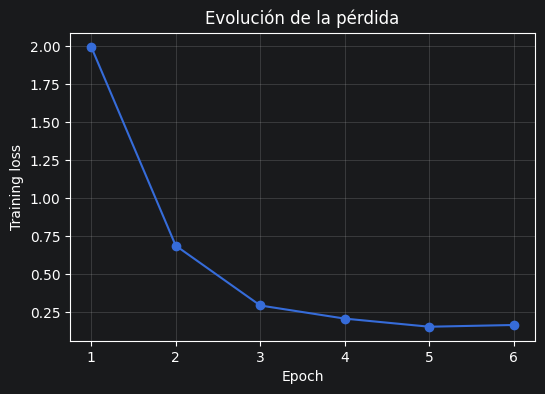

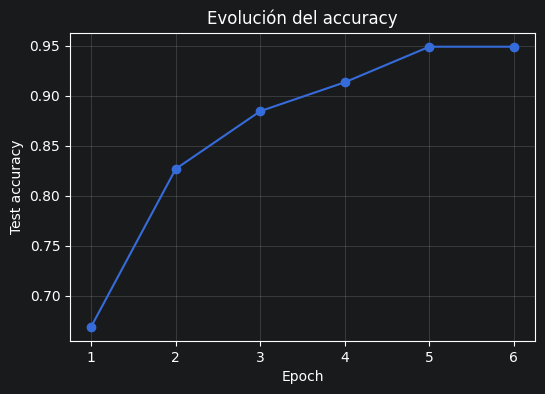

In [15]:
losses = [h[0] for h in history]
accs = [h[1] for h in history]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(losses) + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Evolución de la pérdida")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(accs) + 1), accs, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Evolución del accuracy")
plt.grid(True, alpha=0.3)
plt.show()

# 13. Ejercicios tipo examen resueltos

A continuación se resuelven los ejercicios más representativos del tema. El objetivo es dejar un patrón claro para repetir en examen.

## 13.1 Preguntas tipo test

| Nº | Respuesta correcta | Idea |
|---:|---|---|
| 1 | Una capa convolucional es equivariante a traslaciones | La salida se traslada si la entrada se traslada |
| 2 | No depende de la resolución espacial de la imagen de entrada | Los parámetros dependen de canales y kernel |
| 3 | Tamaño aproximadamente entrada dividida por `s` | El stride reduce resolución |
| 4 | Número de capas convolucionales | Profundidad = número de capas |
| 5 | Mismo tamaño que la entrada | Kernel 11 y padding 5 con stride 1 conserva tamaño |
| 6 | `[10, 28, 37, 28, 17, 6]` | Convolución estricta completa |
| 7 | `[3, 10, 22, 34, 46, 40, 25]` | Convolución estricta completa |
| 8 | `nn.Conv1d(1, 1, kernel_size=5, stride=4, padding=2)` | Matriz con kernel parcial al inicio y salto 4 |
| 9 | `nn.Conv1d(1, 1, kernel_size=7, stride=2, padding=0)` | Filas desplazadas de 2 en 2 |
| 10 | `3·3·3·4 + 4` | Pesos + sesgo por filtro |
| 11 | `5·5·3·32` | Sin sesgo: kernel por canal y filtro |
| 12 | `16×5×5` | Fórmula de salida con stride 2 |
| 13 | `kernel_size=7, stride=2, padding=0` | Esa configuración da 10×10, no 12×12 |
| 14 | Aumentando el stride | Mayor stride reduce resolución |
| 15 | Es incorrecto que `1×1` con stride 1 reduzca H, W y C | Solo cambia canales si stride 1 |
| 16 | Apila convoluciones y pooling en un único flujo | Diseño VGG clásico |
| 17 | Combina arquitectura tipo VGG con conexiones residuales | Idea esencial de ResNet |
| 18 | Permite entrenar redes muy profundas con conexiones residuales | Evita degradación de redes profundas simples |

## 13.2 Ejercicio de BatchNorm, ReLU y pérdida

Se tiene:

$$
z = wx + b, \quad w=4, \quad b=1
$$

Después se aplica ReLU, BatchNorm con $\gamma=3$, $\beta=2$ y finalmente:

$$
L = (t-y)^2
$$

Mini-batch:

$$
(1,1), (2,4), (2.2,4.84), (3.4,11.56), (-2.5,6.25)
$$

In [16]:
x = np.array([1, 2, 2.2, 3.4, -2.5], dtype=float)
y = np.array([1, 4, 4.84, 11.56, 6.25], dtype=float)

w, b = 4, 1
gamma, beta = 3, 2

z = w * x + b
h = np.maximum(0, z)
mu = h.mean()
sigma = np.sqrt(((h - mu) ** 2).mean())
t = ((h - mu) / sigma) * gamma + beta
L = (t - y) ** 2

print("x       =", x)
print("z       =", z)
print("h=ReLU  =", h)
print("mu      =", mu)
print("sigma   =", sigma)
print("t=BN(h) =", np.round(t, 4))
print("L       =", np.round(L, 4))
print("Loss media =", L.mean())

x       = [ 1.   2.   2.2  3.4 -2.5]
z       = [ 5.   9.   9.8 14.6 -9. ]
h=ReLU  = [ 5.   9.   9.8 14.6  0. ]
mu      = 7.68
sigma   = 4.904854737910187
t=BN(h) = [ 0.3608  2.8074  3.2967  6.2325 -2.6974]
L       = [ 0.4086  1.4224  2.3819 28.3818 80.0557]
Loss media = 22.530070041714918


## 13.3 Ejercicio de CNN 1D con dos convoluciones

Datos:

$$
x=(1,2,2,3,5)^T, \quad y=12
$$

Dos capas `Conv1d(1,1,kernel_size=3,stride=1,padding=0)`, ambas con kernel de unos y sesgo cero.

### Forward

Primera convolución:

$$
z = [1+2+2,\; 2+2+3,\; 2+3+5] = [5,7,10]
$$

Segunda convolución:

$$
h = [5+7+10] = [22]
$$

Pérdida:

$$
L = |12-22| = 10
$$

### Backward

Como $h>y$:

$$
\frac{\partial L}{\partial h}=1
$$

La segunda convolución reparte ese gradiente sobre sus tres entradas:

$$
\frac{\partial L}{\partial z} = [1,1,1]^T
$$

La primera convolución produce:

$$
\frac{\partial L}{\partial x} = [1,2,3,2,1]^T
$$

## 13.4 Ejercicio de autograd en PyTorch

Grafo:

$$
d=-2a, \quad e=d+b, \quad f=e \cdot c
$$

Con:

$$
a=-1, \quad b=3, \quad c=2
$$

Entonces:

$$
f=(-2a+b)c
$$

Por tanto:

$$
\frac{\partial f}{\partial a} = -2c = -4
$$

In [17]:
a = torch.tensor(-1.0, requires_grad=True)
b = torch.tensor(3.0)
c = torch.tensor(2.0)

f = ((-2 * a) + b) * c
f.backward()

df_da = a.grad
print("f =", f.item())
print("df/da =", df_da.item())

f = 10.0
df/da = -4.0


## 13.5 Ejercicio de shapes en dos convoluciones 2D

Código:

```python
x_org = torch.randn(40, 40)
x0 = x_org[None, None, ...]
cv1 = nn.Conv2d(1, 2, kernel_size=3, stride=1, padding=1, bias=False)
cv2 = nn.Conv2d(2, 1, kernel_size=3, stride=1, padding=1, bias=True)
x1 = cv1(x0)
x2 = cv2(x1)
y = torch.flatten(x2)
```

Resultados:

| Variable | Shape |
|---|---|
| `x0` | `[1, 1, 40, 40]` |
| `x1` | `[1, 2, 40, 40]` |
| `x2` | `[1, 1, 40, 40]` |
| `y` | `[1600]` |

Kernels:

| Capa | Shape del kernel |
|---|---|
| `cv1.weight` | `[2, 1, 3, 3]` |
| `cv2.weight` | `[1, 2, 3, 3]` |

Parámetros:

$$
cv1 = 2 \cdot 1 \cdot 3 \cdot 3 = 18
$$

$$
cv2 = 1 \cdot 2 \cdot 3 \cdot 3 + 1 = 19
$$

$$
P_{total}=37
$$

In [18]:
x_org = torch.randn(40, 40)
x0 = x_org[None, None, ...]
cv1 = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, stride=1, padding=1, bias=False)
cv2 = nn.Conv2d(in_channels=2, out_channels=1, kernel_size=3, stride=1, padding=1, bias=True)
x1 = cv1(x0)
x2 = cv2(x1)
y = torch.flatten(x2)

print("x0:", tuple(x0.shape))
print("x1:", tuple(x1.shape))
print("x2:", tuple(x2.shape))
print("y:", tuple(y.shape))
print("cv1.weight:", tuple(cv1.weight.shape))
print("cv2.weight:", tuple(cv2.weight.shape))
print("Parámetros:", sum(p.numel() for p in list(cv1.parameters()) + list(cv2.parameters())))

x0: (1, 1, 40, 40)
x1: (1, 2, 40, 40)
x2: (1, 1, 40, 40)
y: (1600,)
cv1.weight: (2, 1, 3, 3)
cv2.weight: (1, 2, 3, 3)
Parámetros: 37


# 14. Resumen final

| Concepto | Fórmula / idea clave |
|---|---|
| Longitud convolución completa 1D | $m+n-1$ |
| Salida Conv1d/Conv2d | $\left\lfloor \frac{D_i-K+2P}{S}+1 \right\rfloor$ |
| Parámetros Conv1d | $C_o C_i K + C_o$ |
| Parámetros Conv2d | $C_o C_i K^2 + C_o$ |
| Conv $1\times1$ | Mezcla canales, no cambia $H,W$ si stride 1 |
| Stride | Reduce resolución espacial |
| Padding | Añade ceros en bordes, puede conservar tamaño |
| Dilation | Aumenta campo receptivo sin más parámetros |
| Pooling | Reduce resolución; max pooling da invarianza parcial |
| CNN | Parámetros locales + compartidos |
| VGG | Muchas convoluciones $3\times3$ |
| ResNet | $y=F(x)+x$ |

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">


### Qué hay que saber hacer para el examen

1. Calcular salidas de convoluciones discretas 1D.
2. Identificar `kernel_size`, `stride` y `padding` a partir de una matriz equivalente.
3. Calcular shapes de tensores en PyTorch.
4. Calcular parámetros de capas `Conv1d` y `Conv2d`.
5. Entender por qué las CNNs son adecuadas para imágenes.
6. Diferenciar invarianza y equivarianza.
7. Explicar las ideas de AlexNet, VGG y ResNet.
8. Escribir una CNN básica en PyTorch.


</div>